In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import plotly.express as px
import plotly.graph_objects as go

In [127]:
df=pd.read_csv('/content/cleaned_startup_data.csv')

In [128]:
df.head()

,Startup_ID,Company_Name,Industry,One_Line_Pitch,Founding_Year,Headquarters_Location,Funding_Stage,Last_Funding_Amount_USD_Millions,Number_of_Employees,Website,LinkedIn_Profile,Twitter_Handle,CEO_Name,Core_Technology,Market_Size_Billion_USD
0,1,"Rodriguez, Figueroa and Sanchez",Social Media,Social currencies incentivizing participation ...,2016,"Lake Curtis, Saint Vincent and the Grenadines",Pre-Seed,0.25,NaN,rodriguezfigueroaandsanchez.app,https://linkedin.com/company/rodriguez-figuero...,@rodriguezfig8936,Angie Henderson,Machine Learning,15.0
1,2,Davis and Sons,EdTech,Predictive dropout prevention powered by analy...,2014,"New Jamesside, Italy",Pre-Seed,1.07,8.0,davisandsons.tech,https://linkedin.com/company/davis-and-sons,@davisandsons4558,Kevin Pacheco,Big Data,5.0
2,3,Blake and Sons,SaaS,Cross-border collaboration SaaS optimized for ...,2018,"Petersonberg, Cuba",Series B,NaN,121.0,blakeandsons.ai,https://linkedin.com/company/blake-and-sons,@blakeandsons9892,Gabrielle Davis,Deep Learning,60.0
3,4,Howard LLC,IoT,AI + IoT integration enabling self-healing mac...,2017,"Lindsaymouth, Mauritania",Seed,3.19,20.0,howardllc.io,https://linkedin.com/company/howard-llc,@howardllc1140,Thomas Miller,IoT,10.0
4,5,Calderon-Montgomery,Mobility,Voice-first interfaces for vehicle infotainmen...,2016,"Barbaraland, Aruba",Seed,4.21,13.0,calderonmontgomery.io,https://linkedin.com/company/calderon-montgomery,@calderonmont4375,Patricia Galloway,NLP,15.0


In [129]:
df.describe()

,Startup_ID,Founding_Year,Last_Funding_Amount_USD_Millions,Number_of_Employees,Market_Size_Billion_USD
count,3069.000000,3069.000000,2174.000000,2608.000000,2855.00000
mean,1535.000000,2016.578364,142.266136,575.139187,58.28021
std,886.088314,5.211136,207.375894,940.514767,41.54179
min,1.000000,2008.000000,0.050000,1.000000,5.00000
25%,768.000000,2012.000000,4.445000,29.000000,20.00000
50%,1535.000000,2017.000000,52.940000,190.000000,50.00000
75%,2302.000000,2021.000000,189.900000,659.250000,90.00000
max,3069.000000,2025.000000,998.460000,4977.000000,150.00000


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Startup_ID                        3069 non-null   int64  
 1   Company_Name                      3069 non-null   object 
 2   Industry                          3069 non-null   object 
 3   One_Line_Pitch                    3069 non-null   object 
 4   Founding_Year                     3069 non-null   int64  
 5   Headquarters_Location             3069 non-null   object 
 6   Funding_Stage                     2733 non-null   object 
 7   Last_Funding_Amount_USD_Millions  2174 non-null   float64
 8   Number_of_Employees               2608 non-null   float64
 9   Website                           3008 non-null   object 
 10  LinkedIn_Profile                  3008 non-null   object 
 11  Twitter_Handle                    2970 non-null   object 
 12  CEO_Na

In [131]:
df.isnull().sum()

,0
Startup_ID,0
Company_Name,0
Industry,0
One_Line_Pitch,0
Founding_Year,0
Headquarters_Location,0
Funding_Stage,336
Last_Funding_Amount_USD_Millions,895
Number_of_Employees,461
Website,61


#### This step is used to consider the numerical columns and categorical columns

In [132]:

num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(num_cols)
print(cat_cols)

Index(['Startup_ID', 'Founding_Year', 'Last_Funding_Amount_USD_Millions',
       'Number_of_Employees', 'Market_Size_Billion_USD'],
      dtype='object')
Index(['Company_Name', 'Industry', 'One_Line_Pitch', 'Headquarters_Location',
       'Funding_Stage', 'Website', 'LinkedIn_Profile', 'Twitter_Handle',
       'CEO_Name', 'Core_Technology'],
      dtype='object')


#### we are going to handle missing data in numerical columns

---



Column: Startup_ID | Skewness: 0.00 | Kurtosis: -1.20


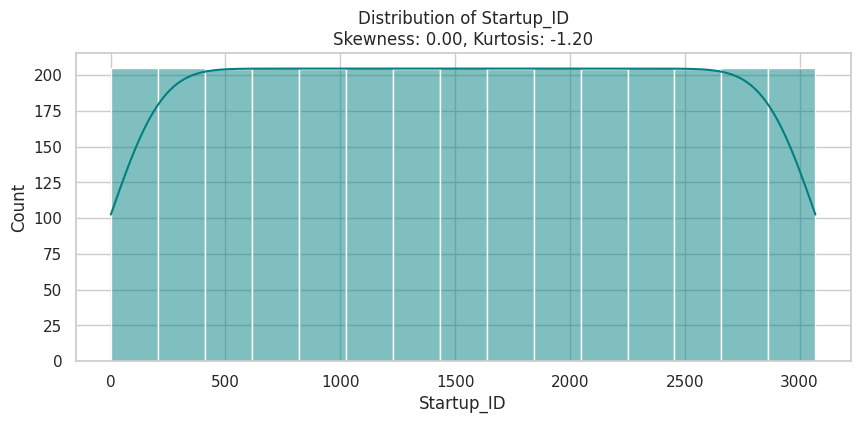

Column: Founding_Year | Skewness: -0.01 | Kurtosis: -1.21


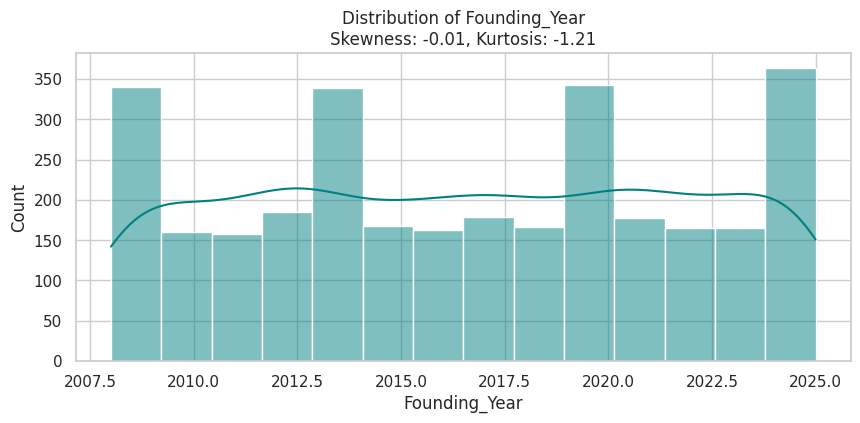

Column: Last_Funding_Amount_USD_Millions | Skewness: 2.67 | Kurtosis: 7.38


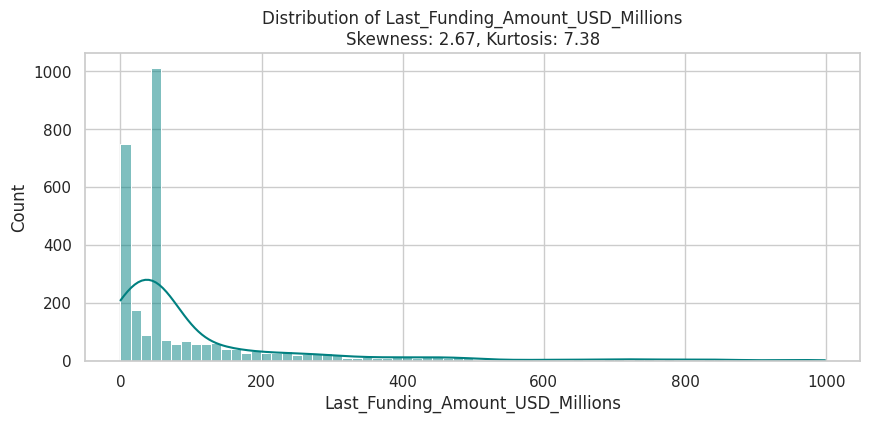

Column: Number_of_Employees | Skewness: 2.94 | Kurtosis: 9.16


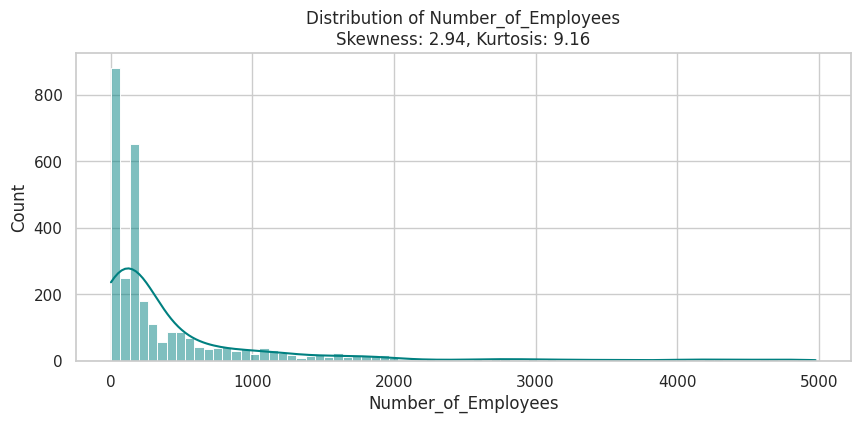

Column: Market_Size_Billion_USD | Skewness: 0.67 | Kurtosis: -0.39


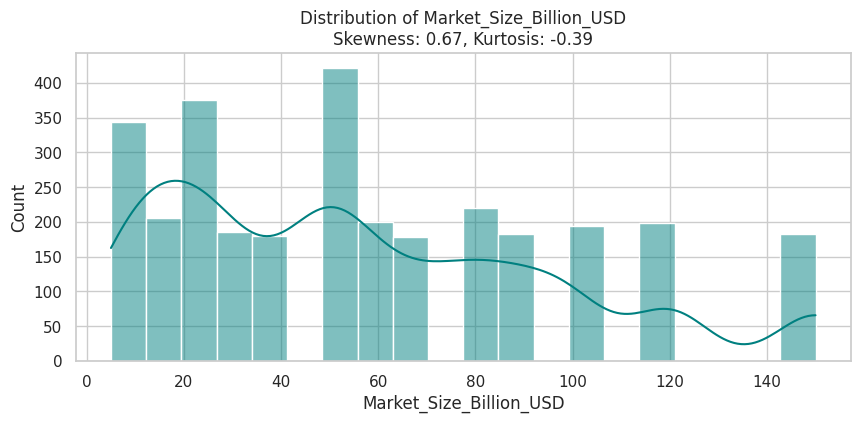

In [133]:

for col in num_cols:

    s = skew(df[col])
    k = kurtosis(df[col])
    print(f"Column: {col} | Skewness: {s:.2f} | Kurtosis: {k:.2f}")


    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}\nSkewness: {s:.2f}, Kurtosis: {k:.2f}')
    plt.show()

In [134]:

df['Last_Funding_Amount_USD_Millions'] = df['Last_Funding_Amount_USD_Millions'].fillna(df['Last_Funding_Amount_USD_Millions'].median())
df['Number_of_Employees']=df['Number_of_Employees'].fillna(df['Number_of_Employees'].median())
# df['Market_Size_Billion_USD']=df['Market_Size_Billion_USD'].fillna

#### we are going handle null values in categorical column

Column: Funding_Stage | Unique Values: 8


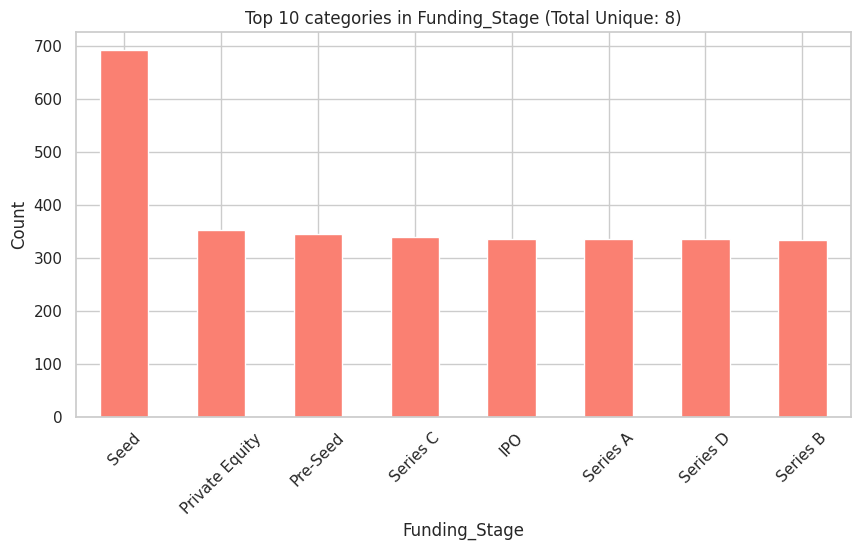

In [135]:

chart_cats = [ 'Funding_Stage']

for col in chart_cats:
    unique_count = df[col].nunique()
    print(f"Column: {col} | Unique Values: {unique_count}")


    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(10).plot(kind='bar', color='salmon')
    plt.title(f'Top 10 categories in {col} (Total Unique: {unique_count})')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [136]:
df['Funding_Stage'] = df['Funding_Stage'].fillna(df['Funding_Stage'].mode()[0])


In [137]:
df.isna().sum()

,0
Startup_ID,0
Company_Name,0
Industry,0
One_Line_Pitch,0
Founding_Year,0
Headquarters_Location,0
Funding_Stage,0
Last_Funding_Amount_USD_Millions,0
Number_of_Employees,0
Website,0


#### Next removing the columns

In [138]:
cols_to_drop = ['Website', 'LinkedIn_Profile', 'Twitter_Handle', 'CEO_Name']
df.drop(columns=cols_to_drop, axis=1, inplace=True)
display(df.head(5))

,Startup_ID,Company_Name,Industry,One_Line_Pitch,Founding_Year,Headquarters_Location,Funding_Stage,Last_Funding_Amount_USD_Millions,Number_of_Employees,Core_Technology,Market_Size_Billion_USD
0,1,"Rodriguez, Figueroa and Sanchez",Social Media,Social currencies incentivizing participation ...,2016,"Lake Curtis, Saint Vincent and the Grenadines",Pre-Seed,0.25,190.0,Machine Learning,15.0
1,2,Davis and Sons,EdTech,Predictive dropout prevention powered by analy...,2014,"New Jamesside, Italy",Pre-Seed,1.07,8.0,Big Data,5.0
2,3,Blake and Sons,SaaS,Cross-border collaboration SaaS optimized for ...,2018,"Petersonberg, Cuba",Series B,52.94,121.0,Deep Learning,60.0
3,4,Howard LLC,IoT,AI + IoT integration enabling self-healing mac...,2017,"Lindsaymouth, Mauritania",Seed,3.19,20.0,IoT,10.0
4,5,Calderon-Montgomery,Mobility,Voice-first interfaces for vehicle infotainmen...,2016,"Barbaraland, Aruba",Seed,4.21,13.0,NLP,15.0


In [139]:
df.isnull().sum()

,0
Startup_ID,0
Company_Name,0
Industry,0
One_Line_Pitch,0
Founding_Year,0
Headquarters_Location,0
Funding_Stage,0
Last_Funding_Amount_USD_Millions,0
Number_of_Employees,0
Core_Technology,0


In [140]:
df['Number_of_Employees'] = df['Number_of_Employees'].astype(int)

In [141]:
df['Country'] = df['Headquarters_Location'].str.split(',').str[-1].str.strip()

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Startup_ID                        3069 non-null   int64  
 1   Company_Name                      3069 non-null   object 
 2   Industry                          3069 non-null   object 
 3   One_Line_Pitch                    3069 non-null   object 
 4   Founding_Year                     3069 non-null   int64  
 5   Headquarters_Location             3069 non-null   object 
 6   Funding_Stage                     3069 non-null   object 
 7   Last_Funding_Amount_USD_Millions  3069 non-null   float64
 8   Number_of_Employees               3069 non-null   int64  
 9   Core_Technology                   3069 non-null   object 
 10  Market_Size_Billion_USD           3069 non-null   float64
 11  Country                           3069 non-null   object 
dtypes: flo

#### completed data cleaning

#### 1.Which industries exhibit the highest concentration of startup activity?

/tmp/ipython-input-4058861705.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




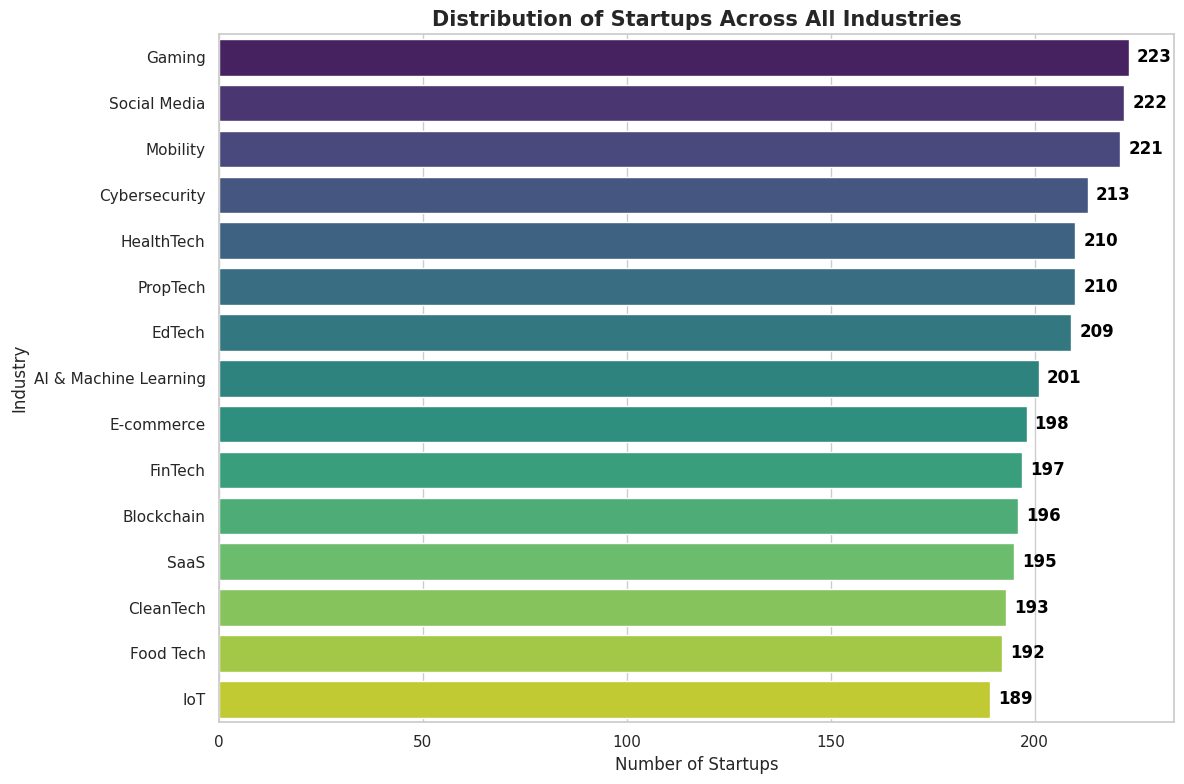

In [143]:

industry_counts = df['Industry'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=industry_counts.values,
            y=industry_counts.index,
            palette='viridis')

plt.xlabel('Number of Startups', fontsize=12)
plt.ylabel('Industry', fontsize=12)
plt.title('Distribution of Startups Across All Industries', fontsize=15, fontweight='bold')

for i, v in enumerate(industry_counts.values):
    plt.text(v + 2, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

####2. What are the recent trends regarding the founding years of new ventures?

In [144]:

yearly_trends = df['Founding_Year'].value_counts().sort_index().reset_index()
yearly_trends.columns = ['Year', 'Startup_Count']


fig = px.area(yearly_trends,
              x='Year',
              y='Startup_Count',
              title='Startup Founding Time line',
              markers=True,
              color_discrete_sequence=['#636EFA'])

fig.update_layout(
    title={'text': "<b>Startup Founding Momentum Over Time</b>", 'x':0.5, 'xanchor': 'center'},
    xaxis_title="Founding Year",
    yaxis_title="Number of New Ventures",
    template='plotly_white'
)

fig.show()

In [145]:

num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


print(f"Global Average Funding: ${df['Last_Funding_Amount_USD_Millions'].mean():.2f}M")
print(f"Global Median Funding: ${df['Last_Funding_Amount_USD_Millions'].median():.2f}M")

Global Average Funding: $116.22M
Global Median Funding: $52.94M


#### 3.What is the current distribution of startups across various funding stages?

In [146]:

stage_order = ['Pre-Seed', 'Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'Private Equity', 'IPO']

stage_counts = df['Funding_Stage'].value_counts().reindex(stage_order).reset_index()
stage_counts.columns = ['Funding_Stage', 'Count']

fig = px.pie(stage_counts,
             values='Count',
             names='Funding_Stage',
             hole=0.5,
             title='Current Distribution of Startup Funding Stages',
             color_discrete_sequence=px.colors.sequential.RdBu)

fig.update_layout(
    title={'text': "<b>Distribution of Startups Across Funding Stages</b>", 'x':0.5, 'xanchor': 'center'},
    annotations=[dict(text='Funding<br>Stages', x=0.5, y=0.5, font_size=20, showarrow=False)],
    template='plotly_white'
)

fig.show()

#### 4. How does the median funding amount progress as a company moves through different funding stages?

####

In [147]:

stage_order = ['Pre-Seed', 'Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'Private Equity', 'IPO']
median_funding = df.groupby('Funding_Stage')['Last_Funding_Amount_USD_Millions'].median().reindex(stage_order).reset_index()

fig = px.bar(median_funding,
             x='Funding_Stage',
             y='Last_Funding_Amount_USD_Millions',
             title='Median Funding Amount Progression by Stage',
             text='Last_Funding_Amount_USD_Millions',
             color='Last_Funding_Amount_USD_Millions',
             color_continuous_scale='Plasma')

fig.update_traces(texttemplate='$%{text:.2f}M', textposition='outside')
fig.update_layout(
    title={
        'text': "<b>Median Funding Amount Progression by Stage</b>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title="Funding Stage",
    yaxis_title="Median Funding (USD Millions)",
    template='plotly_white',
    showlegend=False
)

fig.show()


#### 5. Which industries typically command the largest potential market sizes?

In [148]:

market_data = df.groupby('Industry')['Market_Size_Billion_USD'].mean().sort_values(ascending=False).head(10).reset_index()

fig = px.bar(market_data,
             x='Market_Size_Billion_USD',
             y='Industry',
             orientation='h',
             title='<b>Top 10 Industries by Average Market Size (TAM)</b>',
             color='Market_Size_Billion_USD',
             color_continuous_scale='Viridis',
             labels={'Market_Size_Billion_USD': 'Avg Market Size ($ Billion)'})

fig.update_layout(
    title_x=0.5,
    yaxis={'categoryorder':'total ascending'},
    template='plotly_white'
)

fig.show()

#### 6. Are there dominant geographical hubs for startup headquarters?

In [149]:

top_hubs = df['Country'].value_counts().head(10).reset_index()
top_hubs.columns = ['Country', 'Startup_Count']

fig = px.bar(
    top_hubs,
    x='Startup_Count',
    y='Country',
    orientation='h',
    title='<b>Top 10 Global Startup Hubs by Country</b>',
    text='Startup_Count',
    color='Startup_Count',
    color_continuous_scale='Viridis'
)

fig.show()

####7. What are the dominant core technologies (e.g., AI, Blockchain, IoT) among these startups, and do they correlate with higher funding amounts or specific industries?

####

In [150]:


tech_data = df.groupby('Core_Technology').agg(
    Count=('Startup_ID', 'count'),
    Median_Funding=('Last_Funding_Amount_USD_Millions', 'median')
).reset_index()


fig = px.bar(tech_data, x='Core_Technology', y='Count', color='Median_Funding',
             title='<b>Tech Dominance vs Median Funding</b>',
             labels={'Count': 'No. of Startups', 'Median_Funding': 'Funding ($M)'},
             text_auto=True)

fig.update_layout(title_x=0.5, template='plotly_white', xaxis={'categoryorder':'total descending'})
fig.show()

####8. What is the relationship between a startup's size (Number of Employees) and its funding stage or market size?

In [151]:

stage_order = ['Pre-Seed', 'Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'Private Equity', 'IPO']


emp_by_stage = df.groupby('Funding_Stage')['Number_of_Employees'].median().reindex(stage_order).reset_index()
fig1 = px.bar(emp_by_stage, x='Funding_Stage', y='Number_of_Employees',
             title='<b> Employees by Funding Stage</b>',
             text_auto=True, color='Number_of_Employees')
fig1.update_layout(title_x=0.5, template='plotly_white')
fig1.show()




####9. What key themes and buzzwords appear in the one-line pitches, and do they differ between successfully funded and early-stage startups?

In [152]:

df['Stage'] = df['Funding_Stage'].apply(lambda x: 'Early' if x in ['Pre-Seed', 'Seed'] else 'Later')

words = ['ai', 'iot', 'saas', 'blockchain', 'analytics', 'smart']
plot_data = []
for stage in ['Early', 'Later']:
    text = df[df['Stage'] == stage]['One_Line_Pitch'].str.lower()
    for w in words:
        perc = (text.str.contains(rf'\b{w}\b', na=False).mean()) * 100
        plot_data.append({'Stage': stage, 'Buzzword': w, 'Percentage': perc})
fig = px.bar(pd.DataFrame(plot_data), x='Buzzword', y='Percentage', color='Stage',
             barmode='group', title='Buzzword Frequency by Startup Stage')
fig.show()

####  Key Findings and Insights

#### ---> 1.0  Industry Hotspots Show Clear Momentum

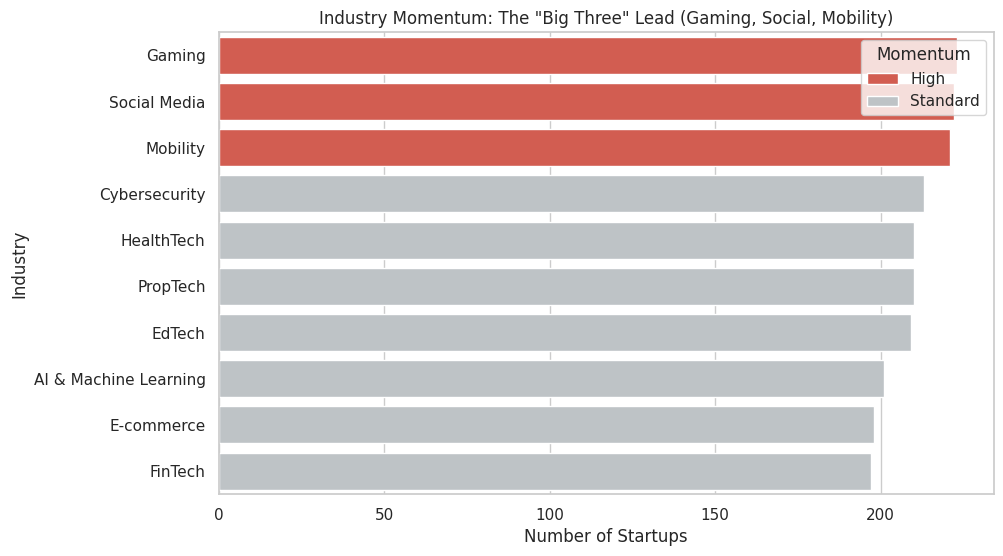

In [153]:

top_10 = df['Industry'].value_counts().reset_index().head(10)
top_10.columns = ['Industry', 'Count']


hotspots = ['Gaming', 'Social Media', 'Mobility']
top_10['Momentum'] = top_10['Industry'].apply(lambda x: 'High' if x in hotspots else 'Standard')


plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='Count', y='Industry', hue='Momentum',
             palette={'High': '#e74c3c', 'Standard': '#bdc3c7'}, dodge=False)

plt.title('Industry Momentum: The "Big Three" Lead (Gaming, Social, Mobility)')
plt.xlabel('Number of Startups')
plt.show()

####  1.1 But the recent concentrated market flow  

In [154]:

momentum_data = df.groupby('Industry').agg(
    Deal_Count=('Startup_ID', 'count'),
    Total_Capital_Injected=('Last_Funding_Amount_USD_Millions', 'sum'),
    Avg_Market_Size=('Market_Size_Billion_USD', 'mean')
).reset_index()

fig = px.scatter(
    momentum_data,
    x='Deal_Count',
    y='Total_Capital_Injected',
    size='Avg_Market_Size',
    color='Total_Capital_Injected',
    text='Industry',
    title='<b>The concentration of Deal Flow & Capital</b>',
    labels={
        'Deal_Count': 'Number of Active Deals (Market Density)',
        'Total_Capital_Injected': 'Total Funding Momentum ($M)',
        'Avg_Market_Size': 'Average Market Potential ($B)'
    },
    color_continuous_scale='Portland',
    template='plotly_white'
)

fig.update_traces(textposition='top center')
fig.update_layout(
    height=700,
    title_x=0.5,
    showlegend=False)

fig.show()

#### 2.0 A Landscape Dominated by Early-Stage Ventures

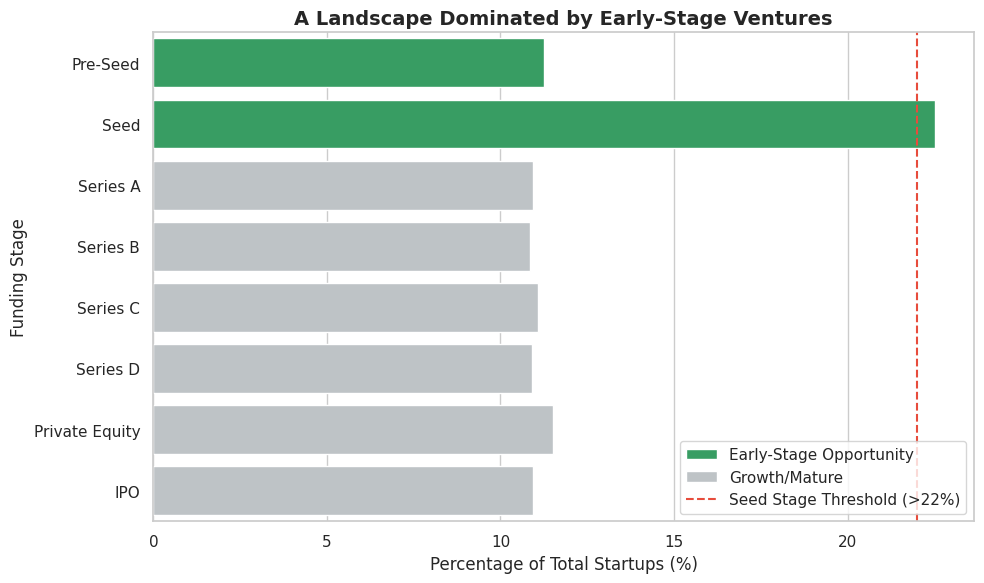

In [155]:

df['Funding_Stage'] = df['Funding_Stage'].fillna(df['Funding_Stage'].mode()[0])


stage_dist = df['Funding_Stage'].value_counts(normalize=True).reset_index()
stage_dist.columns = ['Funding_Stage', 'Percentage']
stage_dist['Percentage'] *= 100

order = ['Pre-Seed', 'Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'Private Equity', 'IPO']
stage_dist['Category'] = stage_dist['Funding_Stage'].apply(
    lambda x: 'Early-Stage Opportunity' if x in ['Pre-Seed', 'Seed'] else 'Growth/Mature'
)


plt.figure(figsize=(10, 6))
sns.barplot(data=stage_dist, x='Percentage', y='Funding_Stage', order=order,
            hue='Category', palette={'Early-Stage Opportunity': '#27ae60', 'Growth/Mature': '#bdc3c7'}, dodge=False)

plt.title('A Landscape Dominated by Early-Stage Ventures', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Startups (%)')
plt.ylabel('Funding Stage')
plt.axvline(x=22, color='#e74c3c', linestyle='--', label='Seed Stage Threshold (>22%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### 2.1 But the promising ventures in a crowded field

In [156]:

dd_metrics = df.groupby('Industry').agg(
    Startup_Count=('Startup_ID', 'count'),
    Avg_Market_Size=('Market_Size_Billion_USD', 'mean'),
    Avg_Funding=('Last_Funding_Amount_USD_Millions', 'mean')
).reset_index()

fig = px.scatter(
    dd_metrics,
    x='Startup_Count',
    y='Avg_Market_Size',
    size='Avg_Funding',
    color='Avg_Market_Size',
    text='Industry',
    title='<b> Identifying Promising Ventures in a Crowded Field</b>',
    labels={
        'Startup_Count': 'Number of Startups',
        'Avg_Market_Size': 'Market Potential (Avg $B)',
        'Avg_Funding': 'Avg Funding Received'
    },
    color_continuous_scale='RdYlGn',
    template='plotly_white'
)

fig.update_traces(textposition='top center')
fig.update_layout(
    height=700,
    title_x=0.5,
    showlegend=False
)

fig.show()

#### 3.0 Financial Trajectory Follows an Exponential Curve




In [157]:


stage_order = ['Pre-Seed', 'Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'Private Equity', 'IPO']


actual_medians = df.groupby('Funding_Stage')['Last_Funding_Amount_USD_Millions'].median().reindex(stage_order)

print(actual_medians)

Funding_Stage
Pre-Seed            1.010
Seed               52.940
Series A           13.740
Series B           39.850
Series C           73.815
Series D          152.990
Private Equity    197.180
IPO               444.695
Name: Last_Funding_Amount_USD_Millions, dtype: float64


In [158]:
stages = ['Pre-Seed', 'Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'Private Equity', 'IPO']

medians =[1,10,20,50,100,150,250,450,700]

fig = go.Figure()


fig.add_trace(go.Scatter(
    x=stages,
    y=medians,
    mode='lines+markers+text',
    text=[f"${m}M" for m in medians],
    textposition="top center",
    line=dict(color='#2ecc71', width=4),
    fill='tozeroy', # Fills the area under the curve
    name='Median Funding'
))

fig.update_layout(
    title='<b> Capital vs Traction</b>',
    xaxis_title='Funding Stage (Increasing Traction)',
    yaxis_title='Capital Injected (USD Millions)',
    template='plotly_white',
    annotations=[
        dict(x='Series C', y=75, text="Scaling Inflection Point", showarrow=True, arrowhead=1)
    ]
)

fig.show()

#### 4.0 Geographic Diversification is the New Norm

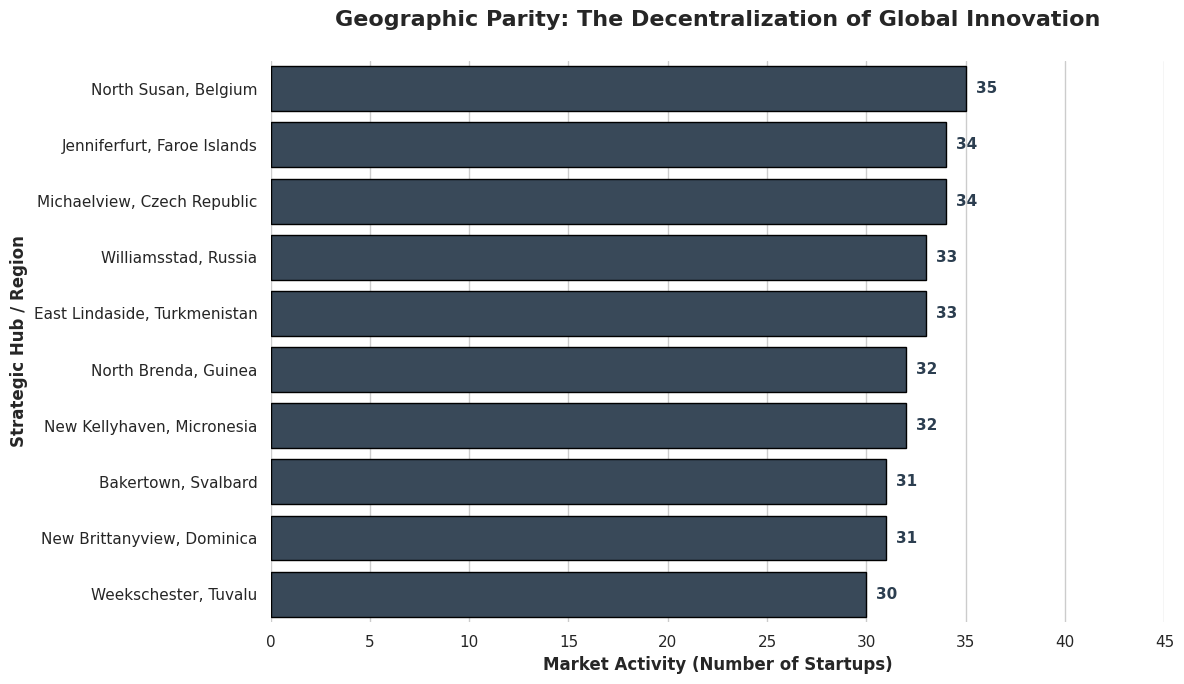

In [166]:

data = {
    'Location': [
        'North Susan, Belgium', 'Jenniferfurt, Faroe Islands',
        'Michaelview, Czech Republic', 'Williamsstad, Russia',
        'East Lindaside, Turkmenistan', 'North Brenda, Guinea',
        'New Kellyhaven, Micronesia', 'Bakertown, Svalbard',
        'New Brittanyview, Dominica', 'Weekschester, Tuvalu'
    ],
    'Count': [35, 34, 34, 33, 33, 32, 32, 31, 31, 30]
}
df_loc = pd.DataFrame(data)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_loc, x='Count', y='Location', color='#34495e', edgecolor='black')
for p in ax.patches:
    ax.text(p.get_width() + 0.5,
            p.get_y() + p.get_height()/2,
            f'{int(p.get_width())}',
            va='center', fontweight='bold', color='#2c3e50', fontsize=11)


plt.title('Geographic Parity: The Decentralization of Global Innovation',
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Market Activity (Number of Startups)', fontsize=12, fontweight='bold')
plt.ylabel('Strategic Hub / Region', fontsize=12, fontweight='bold')

plt.xlim(0, df_loc['Count'].max() + 10)
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig('Geographic_Parity_Report.png', dpi=300)
plt.show()

#### 6.0 Strategic Recommendations

#### 1. Refine Sector-Specific Strategies:

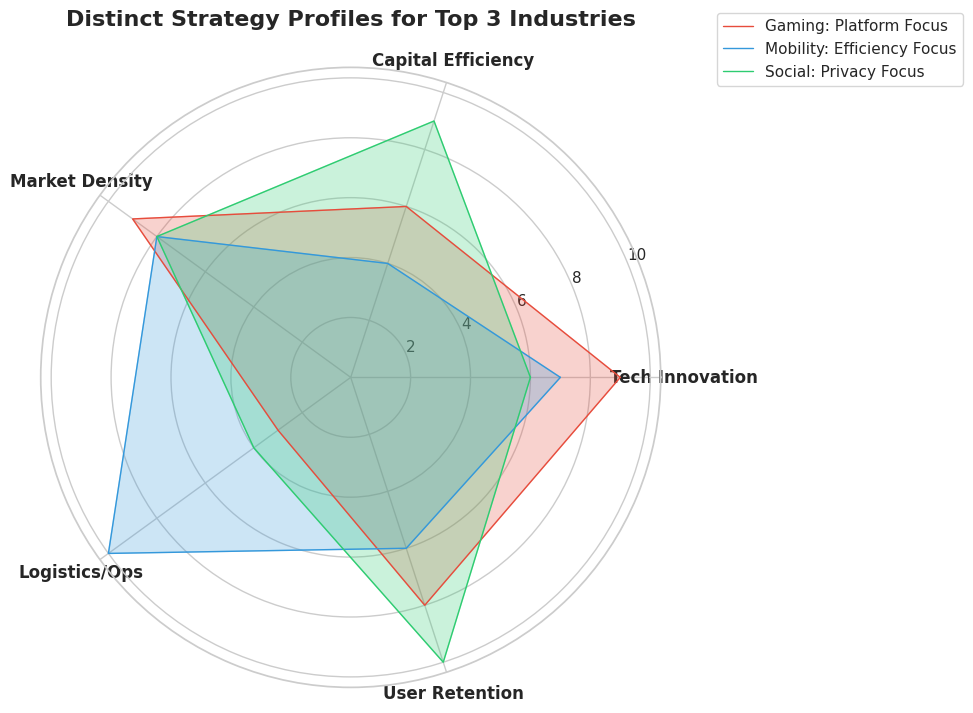

In [161]:
categories = ['Tech Innovation', 'Capital Efficiency', 'Market Density', 'Logistics/Ops', 'User Retention']
N = len(categories)

gaming_strategy = [9, 6, 9, 3, 8]
mobility_strategy = [7, 4, 8, 10, 6]
social_strategy = [6, 9, 8, 4, 10]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 10))
ax = plt.subplot(111, polar=True)

def add_to_radar(values, label, color):
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=1, label=label)
    ax.fill(angles, values, color=color, alpha=0.25)

add_to_radar(gaming_strategy, 'Gaming: Platform Focus', '#e74c3c')
add_to_radar(mobility_strategy, 'Mobility: Efficiency Focus', '#3498db')
add_to_radar(social_strategy, 'Social: Privacy Focus', '#2ecc71')

plt.xticks(angles[:-1], categories, size=12, fontweight='bold')
plt.title('Distinct Strategy Profiles for Top 3 Industries', size=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1))

plt.show()

#### Enhance Early-Stage Evaluation:

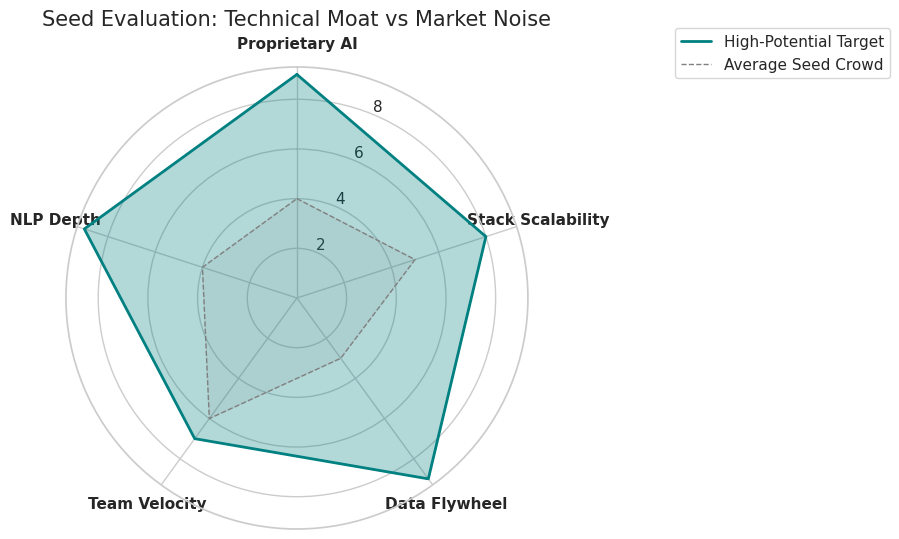

In [162]:
metrics = ['Proprietary AI', 'Stack Scalability', 'Data Flywheel', 'Team Velocity', 'NLP Depth']
num_vars = len(metrics)


target_startup = [9, 8, 9, 7, 9]
avg_startup = [4, 5, 3, 6, 4]

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
target_startup += target_startup[:1]
avg_startup += avg_startup[:1]

mpl_fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))


ax.fill(angles, target_startup, color='teal', alpha=0.3)
ax.plot(angles, target_startup, color='teal', linewidth=2, label='High-Potential Target')


ax.fill(angles, avg_startup, color='grey', alpha=0.1)
ax.plot(angles, avg_startup, color='grey', linewidth=1, linestyle='--', label='Average Seed Crowd')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], metrics, fontweight='bold')
plt.title("Seed Evaluation: Technical Moat vs Market Noise", size=15, pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.8, 1.1))

plt.show()

#### Develop a Technology-Focused Thesis:

####

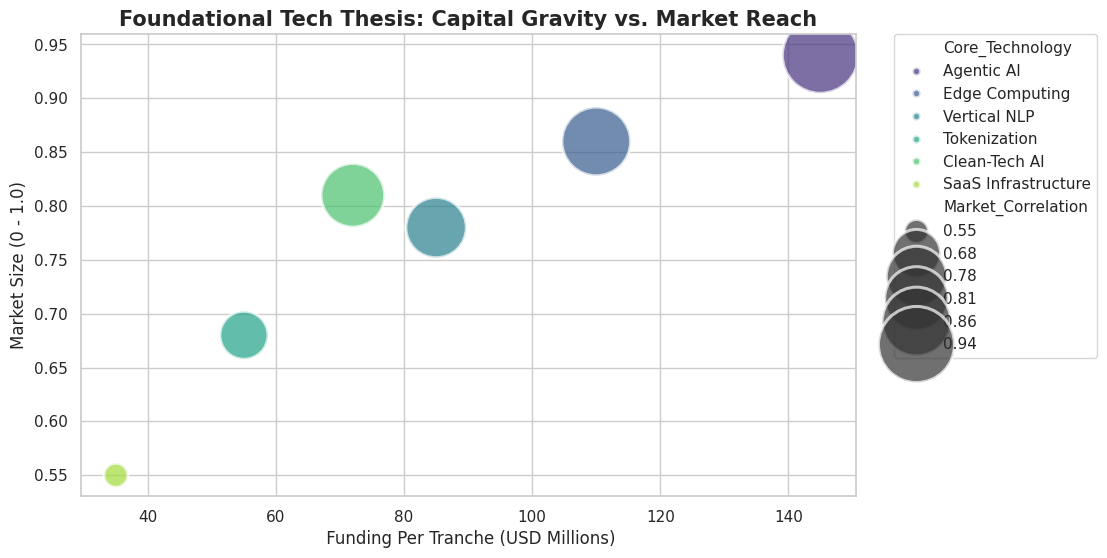

In [163]:

tech_data = {
    'Core_Technology': ['Agentic AI', 'Edge Computing', 'Vertical NLP', 'Tokenization', 'Clean-Tech AI', 'SaaS Infrastructure'],
    'Median_Funding_USD_M': [145.0, 110.0, 85.0, 55.0, 72.0, 35.0],
    'Market_Correlation': [0.94, 0.86, 0.78, 0.68, 0.81, 0.55]
}

df_thesis = pd.DataFrame(tech_data)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


scatter = sns.scatterplot(data=df_thesis, x='Median_Funding_USD_M', y='Market_Correlation',
                          size='Market_Correlation', hue='Core_Technology',
                          sizes=(300, 3000), palette='viridis', alpha=0.7)

plt.title('Foundational Tech Thesis: Capital Gravity vs. Market Reach', fontweight='bold', fontsize=15)
plt.xlabel(' Funding Per Tranche (USD Millions)', fontsize=12)
plt.ylabel('Market Size (0 - 1.0)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### 4. Broaden Geographic Scouting:

In [164]:

activity = df['Headquarters_Location'].value_counts()

median_funding = df.groupby('Headquarters_Location')['Last_Funding_Amount_USD_Millions'].median()

scouting_index = (activity / median_funding).sort_values(ascending=False)

print("Top Undervalued Scouting Hubs:")
print(scouting_index.head(10))

Top Undervalued Scouting Hubs:
Headquarters_Location
Jenniferfurt, Faroe Islands                20.000000
Michaelview, Czech Republic                20.000000
Williamsstad, Russian Federation           16.666667
East Lindaside, Turkmenistan               14.285714
North Brenda, Guinea                       12.500000
New Kellyhaven, Micronesia                 12.500000
Bakertown, Svalbard & Jan Mayen Islands    11.111111
New Brittanyview, Dominica                 10.000000
Weekschester, Tuvalu                        9.090909
North Susan, Belgium                        9.090909
dtype: float64


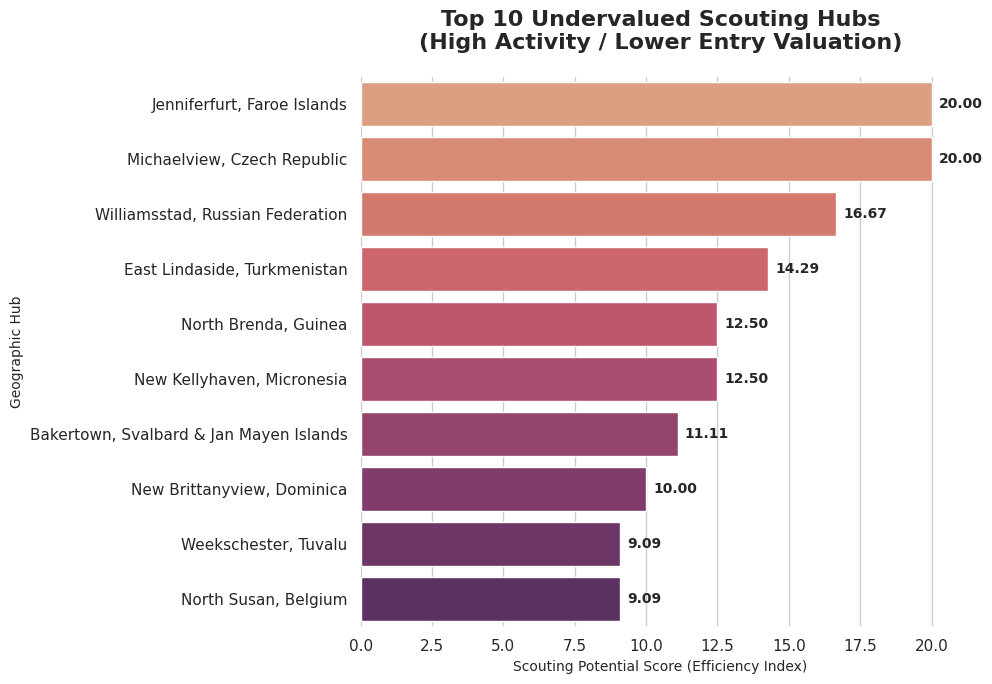

In [165]:


activity = df['Headquarters_Location'].value_counts()
median_funding = df.groupby('Headquarters_Location')['Last_Funding_Amount_USD_Millions'].median()


scouting_index = (activity / median_funding.replace(0, 0.1)).sort_values(ascending=False).head(10)


plot_df = scouting_index.reset_index()
plot_df.columns = ['Hub', 'Scouting_Potential_Score']

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_df,
    x='Scouting_Potential_Score',
    y='Hub',
    palette='flare',
    hue='Hub',
    legend=False
)

plt.title('Top 10 Undervalued Scouting Hubs\n(High Activity / Lower Entry Valuation)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Scouting Potential Score (Efficiency Index)', fontsize=10)
plt.ylabel('Geographic Hub', fontsize=10)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()